In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft YaHei'
plt.rcParams['axes.unicode_minus' ] = False

In [2]:
from lib.model import Model
from lib.dataset import Data
from lib.dataloader.generators import ChunkedGenerator, UnchunkedGenerator
import os
import importlib
import json
import torch
import numpy as np
import cv2
from lib.visualization.utils import *
from lib.train_val.trainer import postprocess_angle

/home/wen/miniconda3/envs/ray3d/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:

exp_path = "/home/wen/ws/ray3d/Ray3D/checkpoint/VIDEOPOSE_h36m_videoOri_FRAME81_LR0.001_EPOCH256_BATCH256_May_24_2025_00_35_40"
model_cfg_json_path = os.path.join(exp_path, "configs", "model_config.json")
dataset_cfg_json_path = os.path.join(exp_path, "configs", "data_config.json")
#ckpt_path = os.path.join(exp_path, "best_epoch.bin")
ckpt_path = os.path.join(exp_path, "best_epoch.bin")

In [4]:
model_cfg, data_cfg = {},{} 
with open(model_cfg_json_path, 'r') as f, open (dataset_cfg_json_path, 'r') as f1:
    model_cfg = json.load(f) 
    data_cfg = json.load(f1) 
receptive_field = model_cfg["NUM_FRAMES"]
pad = (receptive_field - 1) // 2  # Padding on each sid
model_cfg, data_cfg, receptive_field

({'MODEL': 'videoOri',
  'NUM_COARSE_ANG': 16,
  'TRAJECTORY_MODEL': True,
  'BONE_COMPARISON': False,
  'ARCHITECTURE': '3,3,3,3',
  'DROPOUT': 0.25,
  'NUM_FRAMES': 81,
  'CAUSAL': False,
  'CHANNELS': 1024,
  'DENSE': False,
  'NUM_KPTS': 17,
  'INPUT_DIM': 2,
  'DISABLE_OPTIMIZATIONS': False,
  'PRETRAIN': ''},
 {'DATASET': 'h36m',
  'WORLD_3D_GT_EVAL': True,
  'KEYPOINTS': 'gt',
  'TRAIN_SUBJECTS': 'S1,S5,S6,S7,S8',
  'TEST_SUBJECTS': 'S9,S11',
  'GT_3D': 'data/h36m/data_3d_h36m.npz',
  'GT_2D': 'data/h36m/data_2d_h36m_gt.npz',
  'CAMERA_PARAM': '',
  'SUBSET': 1,
  'STRIDE': 1,
  'DOWNSAMPLE': 1,
  'ACTIONS': '*',
  'REMOVE_IRRELEVANT_KPTS': False,
  'FRAME_PATH': '/ssd/yzhan/data/benchmark/3D/showroom/20210702/frame/',
  'ORI_ENCODING': True,
  'INTRINSIC_ENCODING': True,
  'RAY_ENCODING': True,
  'ADD_HEIGHT': False},
 81)

In [5]:
train_delegator = Model(model_cfg, {"ADD_HEIGHT": False}, is_train=False)
model =train_delegator.get_pos_model(); 
    

In [6]:
checkpoint = torch.load(ckpt_path, map_location=lambda storage, loc: storage)

In [7]:
model.load_state_dict(checkpoint["model_pos"], strict=True)
model.eval()

DataParallel(
  (module): TemporalModel(
    (drop): Dropout(p=0.25, inplace=False)
    (relu): ReLU(inplace=True)
    (expand_bn): BatchNorm2d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (cls_head): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1024, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=16, bias=True)
    )
    (reg_head): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1024, out_features=256, bias=True)
      (2): ReLU()
      (3): Linear(in_features=256, out_features=1, bias=True)
      (4): Tanh()
    )
    (expand_conv): Conv2d(34, 1024, kernel_size=(3, 1), stride=(1, 1), bias=False)
    (layers_conv): ModuleList(
      (0): Conv2d(1024, 1024, kernel_size=(3, 1), stride=(1, 1), dilation=(3, 1), bias=False)
      (1): Conv2d(1024, 1024, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (2): Conv2d(1024, 1024, kernel

In [8]:
pose_data = Data(data_cfg)
subjects_train = data_cfg["TRAIN_SUBJECTS"].split(",")
subjects_test = data_cfg["TEST_SUBJECTS"].split(",")
action_filter = None if data_cfg["ACTIONS"] == "*" else data_cfg["ACTIONS"].split(",")
cameras_valid, poses_valid, poses_valid_2d, poses_valid_ori = pose_data.fetch_via_subject(
        subjects_test, action_filter
)
kps_left, kps_right = pose_data.get_2d_kpts()
joints_left, joints_right = pose_data.get_3d_joints()


-------------cal ori-------
-------------cal ori done-------


(array([104., 100., 272., 370.,  94.,  97., 105., 211., 202., 148.]),
 array([4.52535871e-03, 3.59544961e+01, 7.19044668e+01, 1.07854438e+02,
        1.43804408e+02, 1.79754379e+02, 2.15704350e+02, 2.51654320e+02,
        2.87604291e+02, 3.23554262e+02, 3.59504233e+02]),
 <BarContainer object of 10 artists>)

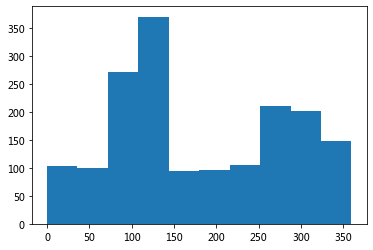

In [9]:
# statistics of ori
plt.hist(poses_valid_ori[0])

In [10]:

test_generator = ChunkedGenerator(
    1,
    cameras_valid,
    poses_valid,
    poses_valid_2d,
    poses_valid_ori,
    1,
    pad=pad,
    causal_shift=False,
    shuffle=False,
    augment=False,
    kps_left=kps_left,
    kps_right=kps_right,
    joints_left=joints_left,
    joints_right=joints_right,
)

processing: 0it [00:00, ?it/s]

109.53637635462069 tensor([227.8885], device='cuda:0', grad_fn=<RemainderBackward0>) [[[118.35217345]]]


processing: 40it [00:02, 23.12it/s]

GIF saved to /tmp/temp_imgs/0.gif


processing: 1975it [00:06, 438.45it/s]

...

GIF saved to /tmp/temp_imgs/28000.gif


processing: 29967it [01:43, 405.52it/s]

80.2422139901993 tensor([162.0901], device='cuda:0', grad_fn=<RemainderBackward0>) [[[81.8478739]]]


processing: 30000it [01:45, 285.33it/s]


KeyboardInterrupt: 

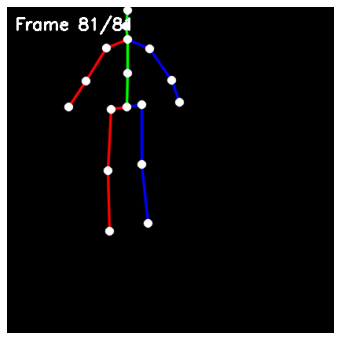

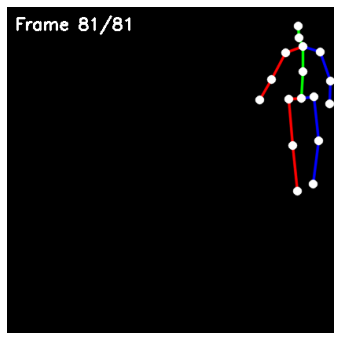

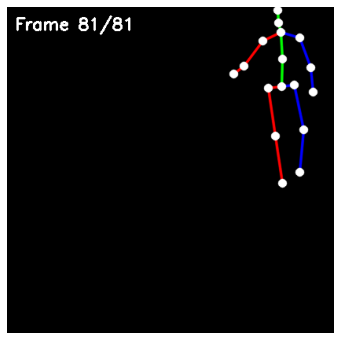

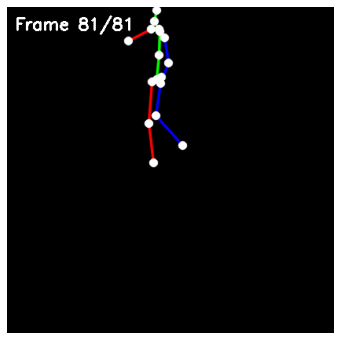

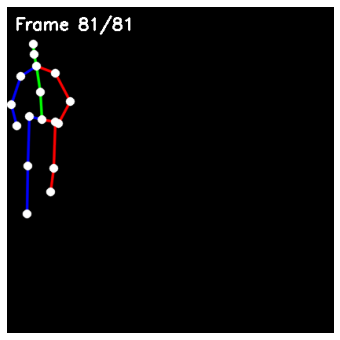

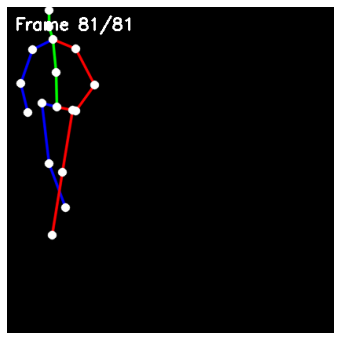

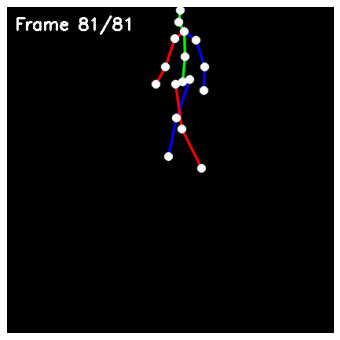

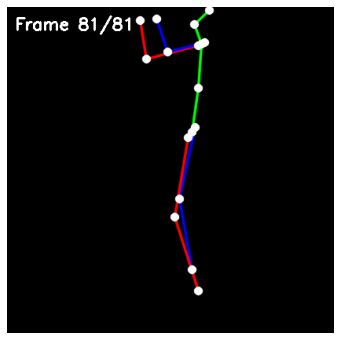

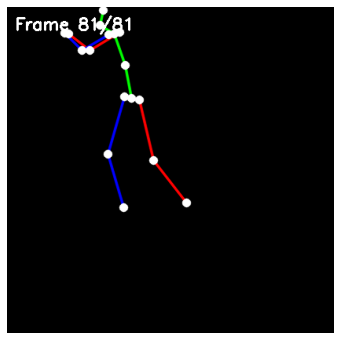

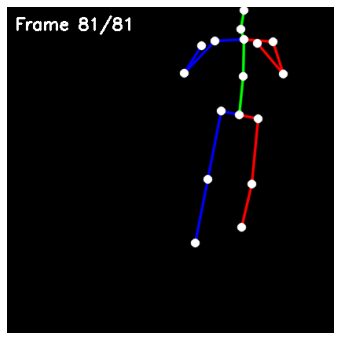

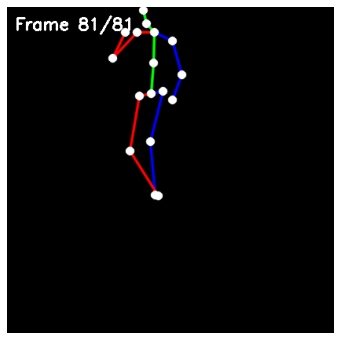

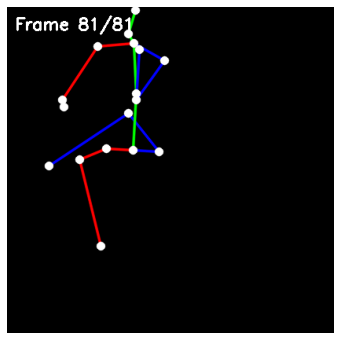

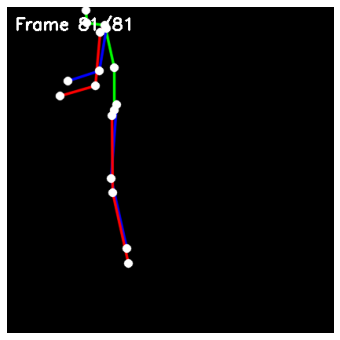

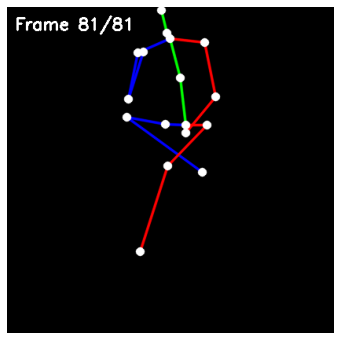

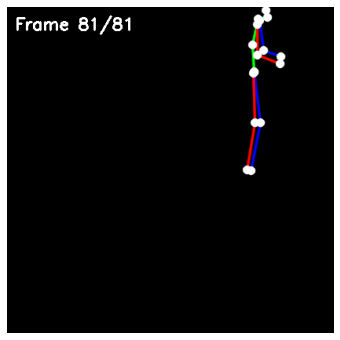

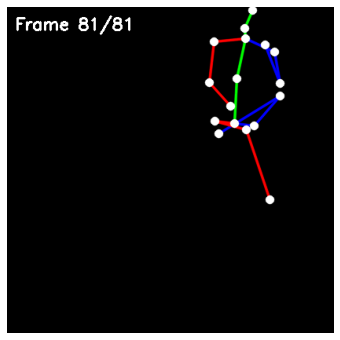

In [12]:
from re import L
from matplotlib.pyplot import arrow
from tqdm import tqdm
from lib.train_val.trainer import postprocess_angle
i = 0

for cam, batch, batch_2d, batch_ori in tqdm(test_generator.next_epoch(), desc="processing"):
    kps_img= draw_kps_to_image(batch_2d[0, batch_2d.shape[1] // 2])
    
    inputs_2d = torch.from_numpy(batch_2d.astype("float32"))
    # print(inputs_2d.shape)
    out_cls, out_reg = model(inputs_2d)
    final_angles, conf = postprocess_angle(out_cls, out_reg, 16)
    delta_angle = abs((batch_ori.squeeze() - final_angles.cpu().detach().numpy().squeeze() + 180.0) % 360.0 - 180.0)
    if  i % 2000 == 0:
        print(delta_angle, final_angles, batch_ori)
        ang_img = draw_orientation(None,batch_ori.squeeze(), conf)
        ang_img = draw_orientation(ang_img, final_angles.cpu().detach().numpy().squeeze(),  conf,arrow_color=(255,0,0))
        cv2.imwrite(f"/tmp/temp_imgs/{i}_{delta_angle}.jpg",cv2.hconcat([kps_img, ang_img]))

        save_kps_gif(batch_2d, f"/tmp/temp_imgs/{i}.gif")
    i += 1
    """ if i > 2000:
        break """

In [ ]:
batch_2d.min(axis=(0,1,2)) , batch_2d.max(axis=(0, 1,2))

In [ ]:
from IPython.display import HTML  # 用于在Jupyter中显示动画
plt.imshow(cv2.hconcat([draw_kps_to_image(batch_2d[0, batch_2d.shape[1] // 2]), draw_orientation(None,batch_ori.squeeze())]))

In [ ]:
plt.imshow(draw_orientation(None,batch_ori.squeeze()))

In [23]:
for cam, batch, batch_2d, batch_ori in test_generator.next_epoch():
    inputs_2d = torch.from_numpy(batch_2d.astype("float32"))
    # print(inputs_2d.shape)
    out_cls, out_reg = model(inputs_2d)
    print(out_reg.cpu().detach().numpy(), torch.argmax(out_cls).cpu().detach().numpy(), postprocess_angle(out_cls, out_reg)[0].cpu().detach().numpy(), batch_ori)

[1.] 2 [112.5] [[[118.35217345]]]
[1.] 2 [112.5] [[[118.34164111]]]
[1.] 2 [112.5] [[[118.3196434]]]
[1.] 2 [112.5] [[[118.3112343]]]
[1.] 2 [112.5] [[[118.29989271]]]
[1.] 2 [112.5] [[[118.30394689]]]
[1.] 2 [112.5] [[[118.29200007]]]
[1.] 2 [112.5] [[[118.27773315]]]
[1.] 2 [112.5] [[[118.27494706]]]
[1.] 2 [112.5] [[[118.27384466]]]
[1.] 2 [112.5] [[[118.29288181]]]
[1.] 2 [112.5] [[[118.29241299]]]
[1.] 2 [112.5] [[[118.27464624]]]
[1.] 2 [112.5] [[[118.2700508]]]
[1.] 2 [112.5] [[[118.34267887]]]
[1.] 2 [112.5] [[[118.25927226]]]
[1.] 2 [112.5] [[[118.24065925]]]
[1.] 2 [112.5] [[[118.21502843]]]
[1.] 2 [112.5] [[[118.1849686]]]
[1.] 2 [112.5] [[[118.15910695]]]
[1.] 2 [112.5] [[[118.13946121]]]
[1.] 2 [112.5] [[[118.11221503]]]
[1.] 2 [112.5] [[[118.0529047]]]
[1.] 2 [112.5] [[[117.89813906]]]
[1.] 2 [112.5] [[[117.7202925]]]
[1.] 2 [112.5] [[[117.48591448]]]
[1.] 2 [112.5] [[[117.32827993]]]
[1.] 2 [112.5] [[[117.17086093]]]
[1.] 2 [112.5] [[[117.05011254]]]
[1.] 2 [112.5] [[[11

KeyboardInterrupt: 

In [14]:
i

(tensor([[-7.5528, -2.0515,  4.7926,  4.6685, -2.8142, -6.3874, -8.1097, -7.9993]],
        device='cuda:0', grad_fn=<AddmmBackward0>),
 tensor([1.], device='cuda:0', grad_fn=<SqueezeBackward1>),
 tensor(2, device='cuda:0'),
 (tensor([112.5000], device='cuda:0', grad_fn=<RemainderBackward0>),
  tensor(0.5305, device='cuda:0', grad_fn=<MaxBackward1>)),
 array([[[118.35217345]]]))

In [ ]:

import numpy as np 
num_bins = 8
bin_width = 360.0 / num_bins
bin_width_half = bin_width / 2.0

# 计算 bin 索引
for i in np.arange(0, 360, 1):
    shifted_angle = (i + bin_width_half) % 360.0
    bin_indices = (shifted_angle // bin_width)
    bin_centers = bin_indices * bin_width
    delta_angle = (i - bin_centers + 180.0) % 360.0 - 180.0
    delta_angle /= bin_width_half
    print(i, bin_indices, delta_angle)